In [1]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape 

(5549563, 6)

In [2]:
ctrl1_data.shape #Bins x Genes

(5549563, 19059)

In [3]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")
gdf.head()
gdf.shape


(11653, 6)

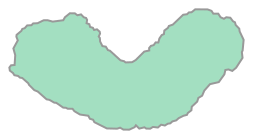

In [4]:
#Sanity Check
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

In [5]:
ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()

s_002um_00000_02609-1    True
s_002um_00000_02610-1    True
s_002um_00000_02611-1    True
s_002um_00000_02612-1    True
s_002um_00000_02613-1    True
                         ... 
s_002um_03347_00386-1    True
s_002um_03347_00387-1    True
s_002um_03347_00388-1    True
s_002um_03347_00389-1    True
s_002um_03347_00390-1    True
Name: proximal_tubule_geojson_feature_index, Length: 5549563, dtype: bool

PROXIMAL TUBULE FILTERING:
This is where I will ytry to filter the proximal tubules based on their 
1. Total Gene Expression
2. Slc34a1 Expression: To make sure we are collectng proximal tubules and dropping distal tubules if any.
3. Shape of the proximal tubule.

In [6]:
#Bootstrapping a few oproximal tubule instances to perform linear regression on:
import pandas as pd
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()].copy() #removing all the NAs
PT_id=ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].unique()
PT_id_rand=pd.Series(PT_id).sample(n=500, random_state=53) #randomly select 5 proximal tubule (geojson IDs)
print(PT_id_rand.tolist())


[1924, 4644, 876, 441, 4575, 5010, 5739, 5593, 5133, 5643, 4893, 60, 4673, 10339, 414, 4277, 5845, 1679, 3827, 236, 4871, 3307, 1105, 5773, 480, 6460, 2948, 1492, 597, 3584, 1838, 279, 1070, 4304, 9515, 8139, 4169, 2555, 2635, 5282, 791, 7411, 9652, 1123, 1926, 6545, 3051, 5938, 4802, 1519, 2721, 3802, 1738, 6613, 2613, 1616, 2979, 4432, 2628, 1995, 3705, 1629, 4696, 1432, 254, 4880, 4161, 1441, 6220, 1169, 3693, 4527, 4578, 1858, 1527, 4328, 4562, 5481, 9517, 2353, 922, 1557, 2193, 4976, 2837, 3053, 4530, 2570, 5531, 8703, 3374, 3737, 2565, 3494, 971, 2046, 6266, 6467, 5419, 10540, 8039, 612, 2754, 511, 6285, 1027, 6122, 4192, 3761, 9206, 10493, 2645, 1347, 3970, 1253, 1944, 3974, 355, 3156, 168, 3770, 3302, 4612, 4035, 6408, 398, 84, 4793, 10605, 2894, 945, 4614, 3540, 4818, 4039, 337, 1761, 1210, 1209, 4781, 5605, 10507, 1556, 1460, 5930, 3146, 4162, 2400, 1610, 1774, 5205, 5182, 7775, 10100, 1560, 2733, 4558, 1263, 43, 4443, 4042, 2292, 5431, 816, 469, 5600, 4813, 4425, 6130, 7393,

proximal_tubule_geojson_feature_index
4     101568.0
5      91334.0
7      45990.0
12     51800.0
13     40081.0
Name: total_counts_per_spot, dtype: float32
Median: 6835
75th percentile: 11717
Number of PTs above median: 797
Filtered Proximal Tubule Indices(>Median): [4, 5, 7, 12, 13, 17, 21, 25, 28, 29]
Number of PTs above q75: 399
Filtered Proximal Tubule Indices (>q75): [4, 5, 7, 12, 13, 17, 21, 25, 28, 29]


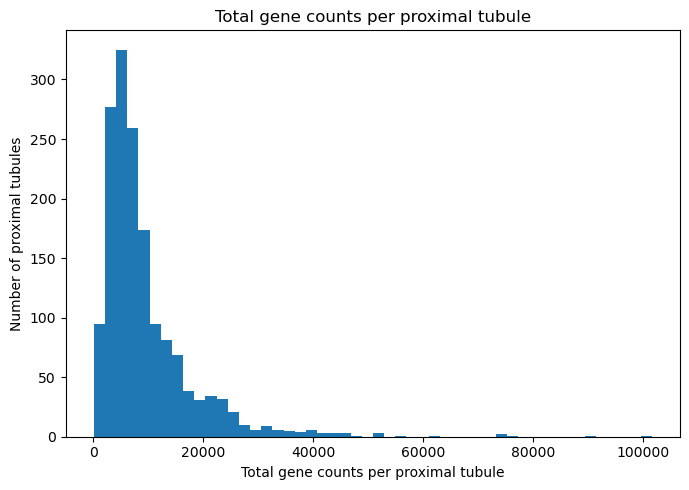

In [21]:
#FILTER1: Trying filter PTs based on their total gene counts:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get proximal tubule IDs
pt_ids = ctrl1_A2_PT.obs["proximal_tubule_geojson_feature_index"]

# Total counts per spot
# (sum across genes for each spot)
spot_counts = np.array(ctrl1_A2_PT.X.sum(axis=1)).flatten()

# Add to obs dataframe
df = ctrl1_A2_PT.obs.copy()
df["total_counts_per_spot"] = spot_counts


# Sum counts across all spots within each proximal tubule (Original Counts)
pt_total_counts = (
    df.groupby("proximal_tubule_geojson_feature_index")[
        "total_counts_per_spot"
    ]
    .sum()
)

print(pt_total_counts.head())

# Plot histogram
plt.figure(figsize=(7,5))

plt.hist(pt_total_counts, bins=50)

plt.xlabel("Total gene counts per proximal tubule")
plt.ylabel("Number of proximal tubules")
plt.title("Total gene counts per proximal tubule")

plt.tight_layout()

# Median
median_counts = pt_total_counts.median() #median of the total gene counts of all proximal tubules

# 75th percentile
q75_counts = pt_total_counts.quantile(0.75) #75th quantile of the total gene counts of all proximal tubules

print(f"Median: {median_counts:.0f}")
print(f"75th percentile: {q75_counts:.0f}")

pt_ids_above_median = pt_total_counts[pt_total_counts > median_counts].index
pt_ids_above_q75 = pt_total_counts[pt_total_counts > q75_counts].index

print(f"Number of PTs above median: {len(pt_ids_above_median)}")
print(f"Filtered Proximal Tubule Indices(>Median): {pt_ids_above_median[:10].tolist()}")  # first 10 IDs

print(f"Number of PTs above q75: {len(pt_ids_above_q75)}")
print(f"Filtered Proximal Tubule Indices (>q75): {pt_ids_above_q75[:10].tolist()}")  # first 10 IDs

#pt_ids_above_median

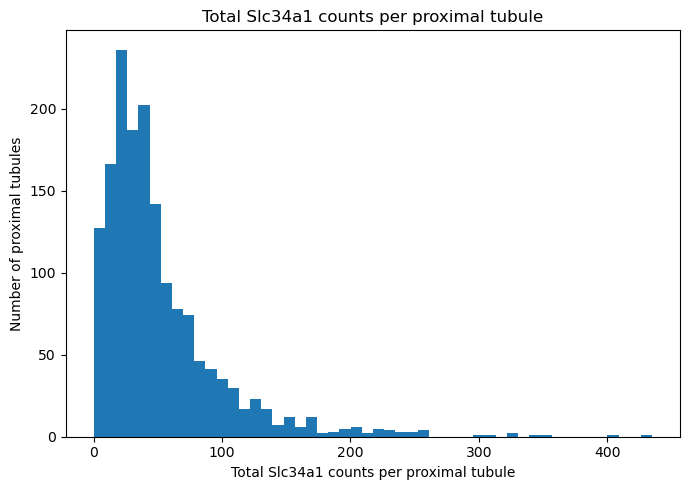

Median: 38
75th percentile: 65
Number of PTs above median: 786
Filtered Proximal Tubule Indices(>Median): [4, 5, 7, 12, 13, 17, 21, 25, 28, 29]
Number of PTs above q75: 397
Filtered Proximal Tubule Indices (>q75): [4, 5, 7, 12, 13, 17, 21, 25, 28, 29]


In [25]:
#FILTER2 (Subsetting based on pan proximal tubule marker)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gene of interest (Pan proximal tubule marker)
gene = "Slc34a1"

# Extract gene expression per spot
gene_expr = np.array(
    ctrl1_A2_PT[:, gene].X.toarray()
).flatten()

# Build dataframe
df = ctrl1_A2_PT.obs.copy()

df["Slc34a1_counts"] = gene_expr

# Sum expression across spots within each PT
pt_Slc34a1_counts = (
    df.groupby("proximal_tubule_geojson_feature_index")[
        "Slc34a1_counts"
    ]
    .sum()
)

# Plot histogram
plt.figure(figsize=(7,5))

plt.hist(pt_Slc34a1_counts, bins=50)

plt.xlabel("Total Slc34a1 counts per proximal tubule")
plt.ylabel("Number of proximal tubules")
plt.title("Total Slc34a1 counts per proximal tubule")

plt.tight_layout()
plt.show()

# Median
median_counts = pt_Slc34a1_counts.median() #median of the total Slc34a1 gene counts of all proximal tubules

# 75th percentile
q75_counts = pt_Slc34a1_counts.quantile(0.75) #75th quantile of the total Slc34a1 gene counts of all proximal tubules

print(f"Median: {median_counts:.0f}")
print(f"75th percentile: {q75_counts:.0f}")

pt_ids_above_median = pt_Slc34a1_counts[pt_Slc34a1_counts > median_counts].index
pt_ids_above_q75 = pt_Slc34a1_counts[pt_Slc34a1_counts > q75_counts].index

print(f"Number of PTs above median: {len(pt_ids_above_median)}")
print(f"Filtered Proximal Tubule Indices(>Median): {pt_ids_above_median[:10].tolist()}")  # first 10 IDs

print(f"Number of PTs above q75: {len(pt_ids_above_q75)}")
print(f"Filtered Proximal Tubule Indices (>q75): {pt_ids_above_q75[:10].tolist()}")  # first 10 IDs



None


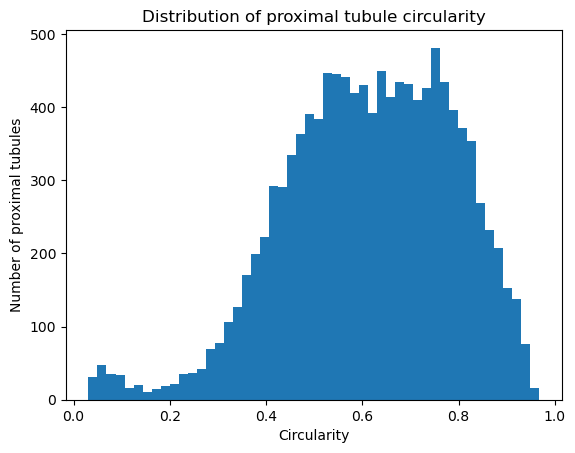

Median: 0.624
75th percentile: 0.751


[5,
 11,
 13,
 21,
 26,
 34,
 41,
 85,
 91,
 105,
 112,
 127,
 231,
 274,
 276,
 285,
 293,
 306,
 324,
 331,
 338,
 339,
 344,
 363,
 371,
 404,
 432,
 499,
 513,
 534,
 541,
 583,
 589,
 592,
 620,
 638,
 668,
 675,
 718,
 758,
 801,
 837,
 862,
 903,
 911,
 918,
 939,
 948,
 1015,
 1080,
 1192,
 1199,
 1213,
 1339,
 1349,
 1360,
 1401,
 1409,
 1429,
 1479,
 1488,
 1535,
 1586,
 1587,
 1631,
 1696,
 1708,
 1717,
 1743,
 1789,
 1822,
 1877,
 1970,
 2025,
 2058,
 2133,
 2166,
 2199,
 2203,
 2209,
 2264,
 2269,
 2273,
 2307,
 2337,
 2445,
 2461,
 2611,
 2660,
 2685,
 2756,
 2770,
 2787,
 2811,
 2825,
 2846,
 2855,
 2968,
 3083,
 3144,
 3252,
 3440,
 3479,
 3566,
 3686,
 3826,
 3910,
 4002,
 4063,
 4073,
 4149,
 4338,
 4383,
 4416,
 4460,
 4588,
 4725,
 4731,
 4843,
 4849,
 5022,
 5115,
 5161,
 5215,
 5220,
 5250,
 5267,
 5302,
 5346,
 5355,
 5475,
 5574,
 5583,
 5611,
 5618,
 5695,
 5715,
 5951,
 5977,
 6038,
 6046,
 6047,
 6171,
 6298,
 6302,
 6421,
 6439,
 6447,
 6471,
 6575,
 6587,
 

In [93]:
#FILTER3 (Subsetting based on geometry of proximal tubules)
#Importing the geojson files which contains the proximal tubule annotations and boudary information.

print(gdf.crs) #to check if GeoPandas is treating your pixel coordinates as geographic coordinates.

gdf = gdf.set_crs(None, allow_override=True) #To remove the incorrect CRS assignment.


import numpy as np

gdf["area"] = gdf.geometry.area
gdf["perimeter"] = gdf.geometry.length

gdf["circularity"] = (
    4 * np.pi * gdf["area"] / (gdf["perimeter"] ** 2)
)

gdf[["circularity"]].head()


import matplotlib.pyplot as plt

plt.figure()
plt.hist(gdf["circularity"].dropna(), bins=50)
plt.xlabel("Circularity")
plt.ylabel("Number of proximal tubules")
plt.title("Distribution of proximal tubule circularity")
plt.show()

# Median
median_counts =gdf["circularity"].median() #median of the circularity of all proximal tubules

q75_counts =gdf["circularity"].quantile(0.75) #75th quantile of the circularity of all proximal tubules

print(f"Median: {median_counts:.3f}")
print(f"75th percentile: {q75_counts:.3f}")

pt_ids_above_median = gdf[(gdf["circularity"]>(median_counts-0.05))&(gdf["circularity"]<(median_counts+0.05))]
pt_ids_above_median.index.to_list()

pt_ids_filt1=gdf[gdf["circularity"]<0.2]
#pt_ids_filt1=gdf[(gdf["circularity"]>(0.3))&(gdf["circularity"]<(0.5))]
pt_ids_filt1.index.to_list()
                 

#pt_ids_above_q75 = pt_Slc34a1_counts[pt_Slc34a1_counts > q75_counts].index




In [95]:
gdf.loc[482, "circularity"]

np.float64(0.8464853560223256)

None


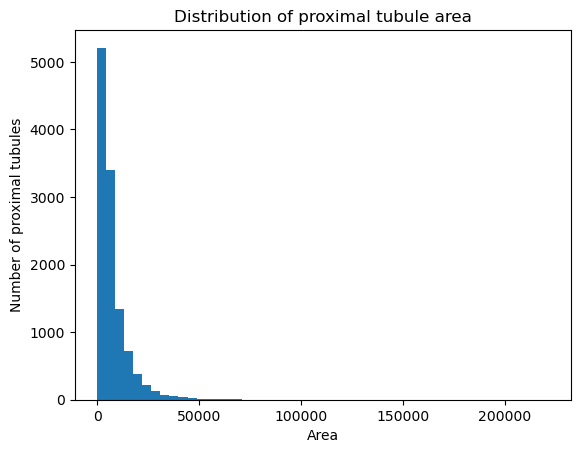

Median: 5074.000
75th percentile: 9132.465


[2548,
 3627,
 3746,
 4988,
 5148,
 5261,
 5269,
 5280,
 5334,
 5378,
 5398,
 5403,
 5417,
 5423,
 5425,
 5426,
 5427,
 5428,
 5430,
 5433,
 5434,
 5436,
 5438,
 5439,
 5440,
 5441,
 5442,
 5443,
 5444,
 5445,
 5447,
 5449,
 5450,
 5451,
 5452,
 5453,
 5454,
 5455,
 5456,
 5457,
 5458,
 5459,
 5460,
 5461,
 5462,
 5463,
 5464,
 5465,
 5466,
 5467,
 5468,
 5469,
 5470,
 5471,
 5473,
 5474,
 5476,
 5477,
 5479,
 5480,
 5481,
 5482,
 5484,
 5485,
 5486,
 5487,
 5490,
 5491,
 5492,
 5493,
 5494,
 5496,
 5497,
 5498,
 5499,
 5500,
 5501,
 5502,
 5503,
 5504,
 5506,
 5507,
 5508,
 5509,
 5510,
 5511,
 5512,
 5513,
 5514,
 5515,
 5516,
 5517,
 5518,
 5520,
 5521,
 5522,
 5524,
 5525,
 5526,
 5527,
 5528,
 5529,
 5530,
 5531,
 5532,
 5533,
 5534,
 5535,
 5536,
 5537,
 5538,
 5539,
 5540,
 5541,
 5542,
 5543,
 5544,
 5545,
 5546,
 5547,
 5548,
 5549,
 5550,
 5551,
 5552,
 5553,
 5554,
 5555,
 5556,
 5557,
 5558,
 5559,
 5560,
 5561,
 5562,
 5563,
 5564,
 5565,
 5566,
 5567,
 5568,
 5569,
 5570,

In [ ]:
#FILTER4 (Subsetting based on geometry (area) of proximal tubules)
#Importing the geojson files which contains the proximal tubule annotations and boudary information.

print(gdf.crs) #to check if GeoPandas is treating your pixel coordinates as geographic coordinates.

gdf = gdf.set_crs(None, allow_override=True) #To remove the incorrect CRS assignment.


import numpy as np

gdf["area"] = gdf.geometry.area
gdf["perimeter"] = gdf.geometry.length

import matplotlib.pyplot as plt

plt.figure()
plt.hist(gdf["area"].dropna(), bins=50)
plt.xlabel("Area")
plt.ylabel("Number of proximal tubules")
plt.title("Distribution of proximal tubule area")
plt.show()

# Median
median_counts =gdf["area"].median() #median of the circularity of all proximal tubules

q75_counts =gdf["area"].quantile(0.75) #75th quantile of the circularity of all proximal tubules

print(f"Median: {median_counts:.3f}")
print(f"75th percentile: {q75_counts:.3f}")

pt_ids_above_median = gdf[(gdf["area"]>(median_counts*0.9))&(gdf["area"]<(median_counts*1.1))]
pt_ids_above_median.index.to_list()

#pt_ids_filt1=gdf[gdf["circularity"]<median_counts]
#pt_ids_filt1.index.to_list()
                 

#pt_ids_above_q75 = pt_Slc34a1_counts[pt_Slc34a1_counts > q75_counts].index

In [10]:
#Bootstrapping a few oproximal tubule instances to perform linear regression on:
import pandas as pd
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()].copy() #removing all the NAs
PT_id=ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].unique()
PT_id_rand=pd.Series(PT_id).sample(n=500, random_state=53) #randomly select 5 proximal tubule (geojson IDs)
print(PT_id_rand.tolist())


[1924, 4644, 876, 441, 4575, 5010, 5739, 5593, 5133, 5643, 4893, 60, 4673, 10339, 414, 4277, 5845, 1679, 3827, 236, 4871, 3307, 1105, 5773, 480, 6460, 2948, 1492, 597, 3584, 1838, 279, 1070, 4304, 9515, 8139, 4169, 2555, 2635, 5282, 791, 7411, 9652, 1123, 1926, 6545, 3051, 5938, 4802, 1519, 2721, 3802, 1738, 6613, 2613, 1616, 2979, 4432, 2628, 1995, 3705, 1629, 4696, 1432, 254, 4880, 4161, 1441, 6220, 1169, 3693, 4527, 4578, 1858, 1527, 4328, 4562, 5481, 9517, 2353, 922, 1557, 2193, 4976, 2837, 3053, 4530, 2570, 5531, 8703, 3374, 3737, 2565, 3494, 971, 2046, 6266, 6467, 5419, 10540, 8039, 612, 2754, 511, 6285, 1027, 6122, 4192, 3761, 9206, 10493, 2645, 1347, 3970, 1253, 1944, 3974, 355, 3156, 168, 3770, 3302, 4612, 4035, 6408, 398, 84, 4793, 10605, 2894, 945, 4614, 3540, 4818, 4039, 337, 1761, 1210, 1209, 4781, 5605, 10507, 1556, 1460, 5930, 3146, 4162, 2400, 1610, 1774, 5205, 5182, 7775, 10100, 1560, 2733, 4558, 1263, 43, 4443, 4042, 2292, 5431, 816, 469, 5600, 4813, 4425, 6130, 7393,

In [38]:
# read the corresponding image:
from PIL import Image
Image.MAX_IMAGE_PIXELS = 1_000_000_000
img = Image.open("data/2um/Ctrl_1A2/Ctrl_1A2.tif")

In [39]:
from shapely.geometry import Polygon, MultiPolygon

def plot_tubule_patch(gdf, img, tubule_id="929", buffer=200):
    # Get geometry
    tubule = gdf[gdf["id"] == str(tubule_id)]
    if tubule.empty:
        raise ValueError(f"Tubule {tubule_id} not found")
    
    geom = tubule.geometry.iloc[0]

    # Bounding box (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = geom.bounds

    # Add buffer
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer

    # Clamp to image bounds
    width, height = img.size
    minx = max(0, int(minx))
    miny = max(0, int(miny))
    maxx = min(width, int(maxx))
    maxy = min(height, int(maxy))

    # Crop image
    crop = img.crop((minx, miny, maxx, maxy))

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(crop)

    # Helper to plot polygon(s)
    def plot_geom(g):
        if isinstance(g, Polygon):
            x, y = g.exterior.xy
            # shift coords into cropped frame
            x = [xi - minx for xi in x]
            y = [yi - miny for yi in y]
            ax.plot(x, y, color='red', linewidth=2)
        elif isinstance(g, MultiPolygon):
            for poly in g.geoms:
                plot_geom(poly)

    plot_geom(geom)

    # Flip y-axis to match image coordinates
    ax.set_ylim(crop.size[1], 0)

    ax.set_title(f"Tubule {tubule_id}")
    plt.show()

    #return crop

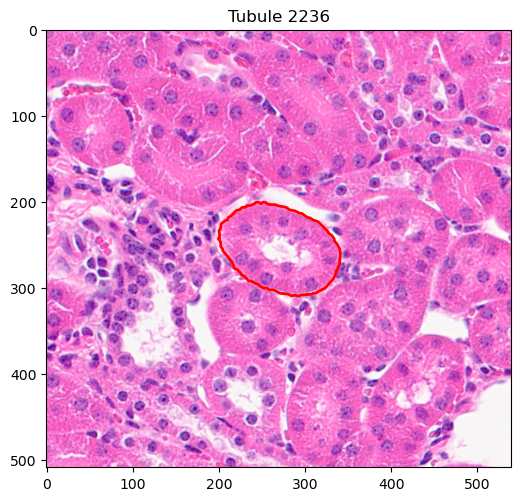

In [50]:
plot_tubule_patch(gdf, img, tubule_id="2236", buffer=200)

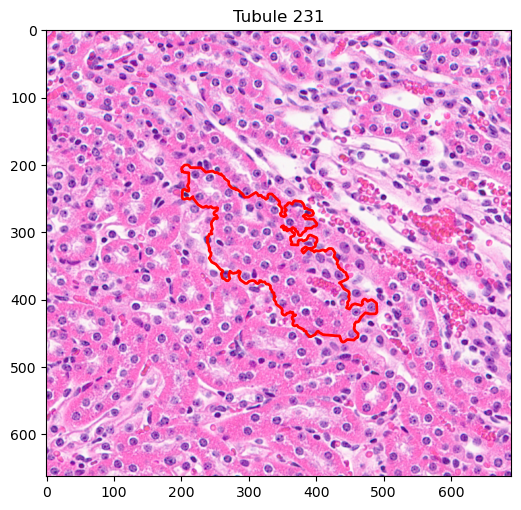

In [94]:
plot_tubule_patch(gdf, img, tubule_id="231", buffer=200)

LINEAR REGRESSION ANALYSIS:
From this step on, I will perform analysis on the filtered proximal tubules and see the expression of genes along the apical-basal axis.

In [62]:
#Convert the five proximal tubules into radial coordinates:
#ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index']==str(PT_id_rand)]
ptoi=PT_id_rand.astype(str).tolist() #proximal tubule of interest
subset=ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].astype(str).isin(ptoi)].copy()
subset.shape #Bins x Genes

(276784, 19059)

In [63]:
#Non dimensionalizing the x and y coordinates
x = subset.obs["pxl_col_in_fullres"]
y = subset.obs["pxl_row_in_fullres"]

#Convert bins to shapely points:
from shapely.geometry import Point
points = [Point(xy) for xy in zip(x, y)]

#Extract the polygon boundary:
boundary = geom.boundary

#Computing distance to edge:
distances = [p.distance(boundary) for p in points]

#Append this new distance matrix into the subset data:
subset.obs["dist_to_edge"] = distances
subset.obs["dist_to_edge"] = subset.obs["dist_to_edge"].values/max(subset.obs["dist_to_edge"].values)
subset.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index,dist_to_edge
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929,0.000013
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929,0.000038
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929,0.000137
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929,0.000073
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929,0.000117
...,...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938,0.818540
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938,0.818626
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938,0.818713
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938,0.818799


In [65]:
#Converting the x and y coordinates into bins (To account for size diiference in different PTs)
import pandas as pd
import numpy as np

# Define bins
#bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bins = [0,0.5, 1.0]

subset.obs["dist_bin"] = pd.cut(
    subset.obs["dist_to_edge"],
    bins=bins,
    labels=False,
    include_lowest=True
)
subset.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index,dist_to_edge,dist_bin
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929,0.000013,0
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929,0.000038,0
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929,0.000137,0
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929,0.000073,0
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929,0.000117,0
...,...,...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938,0.818540,1
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938,0.818626,1
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938,0.818713,1
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938,0.818799,1


In [66]:

bin_means = []
bin_centers = []

for b in range(2):
    mask = subset.obs["dist_bin"] == b
    
    if np.sum(mask) == 0:
        continue
    
    X_bin = subset[mask].X
    
    mean_expr = X_bin.mean(axis=0)
    bin_means.append(np.array(mean_expr).flatten())
    
    # use mean distance of that bin
    bin_centers.append(subset.obs.loc[mask, "dist_to_edge"].mean())

bin_means = np.vstack(bin_means)
bin_centers = np.array(bin_centers).reshape(-1, 1)

In [67]:
betas = []

from sklearn.linear_model import LinearRegression
for g in range(bin_means.shape[1]):
    y = bin_means[:, g]
    
    model = LinearRegression().fit(bin_centers, y)
    betas.append(model.coef_[0])

Edge genes:
 ['mt-Co2', 'Gpx3', 'mt-Co3', 'mt-Atp6', 'mt-Nd1', 'Acy3', 'Acsm2', 'mt-Co1', 'mt-Cytb', 'mt-Atp8', 'Igfbp7', 'Selenop', 'Slc34a1', 'Fth1', 'mt-Nd5', 'Umod', 'Pck1', 'Aldob', 'mt-Nd4l', 'Atp1b1']

Center genes:
 ['Kap', 'Ugt3a2', 'Ehhadh', 'Mep1a', 'Cyb5b', 'Cpt2', 'Mep1b', 'Acadm', 'Cyp51', 'Ubr3', 'Asl', 'Aadac', 'Retsat', 'Bdh1', 'Hint2', 'Slc16a9', 'Pdk2', 'Hist1h2bc', 'Gclc', 'Gipc2']


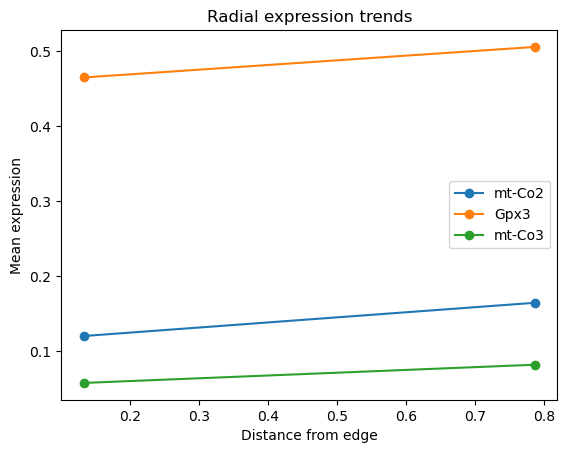

,gene_ids,feature_types,genome,dist_slope
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,0.000006
Rp1,ENSMUSG00000025900,Gene Expression,mm10,-0.000042
Sox17,ENSMUSG00000025902,Gene Expression,mm10,0.000162
Lypla1,ENSMUSG00000025903,Gene Expression,mm10,0.001094
Tcea1,ENSMUSG00000033813,Gene Expression,mm10,0.000186
...,...,...,...,...
mt-Nd4,ENSMUSG00000064363,Gene Expression,mm10,0.008478
mt-Nd5,ENSMUSG00000064367,Gene Expression,mm10,0.017143
mt-Nd6,ENSMUSG00000064368,Gene Expression,mm10,0.001494
mt-Cytb,ENSMUSG00000064370,Gene Expression,mm10,0.022595


In [83]:
subset.var["dist_slope"] = betas

top_center = subset.var.sort_values("dist_slope").head(20) #Only selecting the the top 20 genes
top_edge = subset.var.sort_values("dist_slope", ascending=False).head(20)

print("Edge genes:\n", top_edge.index.tolist())
print("\nCenter genes:\n", top_center.index.tolist())

import matplotlib.pyplot as plt

genes_to_plot = top_edge.index[:3].tolist() #+ top_center.index[:3].tolist()

for gene in genes_to_plot:
    g_idx = subset.var_names.get_loc(gene)
    
    plt.plot(bin_centers, bin_means[:, g_idx], marker='o', label=gene)

plt.xlabel("Distance from edge")
plt.ylabel("Mean expression")
plt.title("Radial expression trends")
plt.legend()
plt.show()

subset.var

In [84]:
gpx3_slope = subset.var.loc["Gpx3", "dist_slope"]
print(f"Gpx3 dist_slope: {gpx3_slope}")

Gpx3 dist_slope: 0.062327660657980434


In [71]:
print(subset.obs["proximal_tubule_geojson_feature_index"].dtype)
print(subset.obs["dist_bin"].dtype)
print(subset.obs[["proximal_tubule_geojson_feature_index", "dist_bin"]].head())

Int64
int64
                       proximal_tubule_geojson_feature_index  dist_bin
s_002um_00304_00021-1                                    929         0
s_002um_00304_00022-1                                    929         0
s_002um_00304_00023-1                                    929         0
s_002um_00304_00024-1                                    929         0
s_002um_00304_00025-1                                    929         0


In [72]:
import numpy as np
import pandas as pd

results = []

# Loop over every proximal tubule
for tubule in subset.obs["proximal_tubule_geojson_feature_index"].dropna().unique():

    # Boolean mask (convert to NumPy bool array)
    mask = (
        subset.obs["proximal_tubule_geojson_feature_index"] == tubule
    ).to_numpy(dtype=bool)

    tub = subset[mask]

    # Loop over every distance bin present in this tubule
    for b in sorted(tub.obs["dist_bin"].dropna().unique()):

        bin_mask = (tub.obs["dist_bin"] == b).to_numpy(dtype=bool)

        if bin_mask.sum() == 0:
            continue

        X = tub[bin_mask].X

        # Mean expression of every gene
        mean_expr = np.asarray(X.mean(axis=0)).ravel()

        # Mean distance of that bin
        mean_dist = tub.obs.loc[bin_mask, "dist_to_edge"].mean()

        # Store one row per gene
        for gene, expr in zip(subset.var_names, mean_expr):

            results.append({
                "tubule": tubule,
                "dist_bin": b,
                "mean_distance": mean_dist,
                "gene": gene,
                "mean_expression": expr
            })

# Convert to DataFrame
results = pd.DataFrame(results)

print(results.head())

   tubule  dist_bin  mean_distance    gene  mean_expression
0     929         0       0.000986    Xkr4         0.000000
1     929         0       0.000986     Rp1         0.000000
2     929         0       0.000986   Sox17         0.000000
3     929         0       0.000986  Lypla1         0.004608
4     929         0       0.000986   Tcea1         0.000000


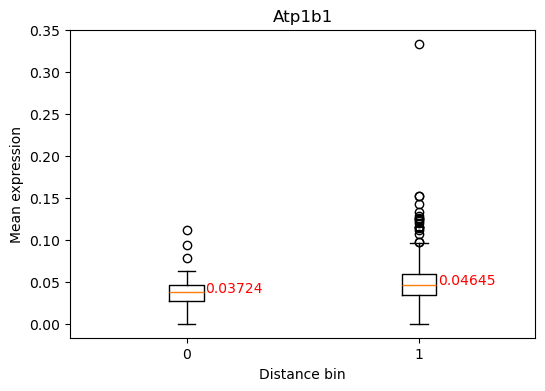

Bin 0: Median = 0.0372
Bin 1: Median = 0.0464


In [82]:
import numpy as np
import matplotlib.pyplot as plt

gene = "Atp1b1"

df = results[results["gene"] == gene]

bins = sorted(df["dist_bin"].unique())

data = [
    df[df["dist_bin"] == b]["mean_expression"].values
    for b in bins
]

medians = [np.median(values) for values in data]

plt.figure(figsize=(6,4))
plt.boxplot(data, tick_labels=bins)

# Annotate median values
for i, median in enumerate(medians, start=1):
    plt.text(i + 0.08, median, f"{median:.5f}",
             color="red", fontsize=10)

plt.xlabel("Distance bin")
plt.ylabel("Mean expression")
plt.title(gene)
plt.show()

# Also print them
for b, median in zip(bins, medians):
    print(f"Bin {b}: Median = {median:.4f}")